In [1]:
import sys

sys.path.insert(0, "/project/src")

import matplotlib.pyplot as plt

from housing import TractBoundariesLoader
from housing.components.analyzers.str_tract_analyzer import STRTractAnalyzer
from housing.components.loaders.community_boundaries import CommunityBoundariesLoader
from housing.components.loaders.str_data import STRDataLoader
from housing.components.processors.str_points_to_tract import STRToTractProcessor
from housing.components.processors.str_tract_to_community import (
    STRTractToCommunityProcessor,
)
from housing.components.visualizers.str_map import STRMapVisualizer
from pipeline import Pipeline
from pipeline.config import PipelineConfig

In [3]:
config = PipelineConfig()
pipeline = Pipeline("STR Coordinate Data", config=config)
pipeline.load_config()

points_processor = STRToTractProcessor(
    input_key="str_data", output_key="str_tract_data", id_column="Submission ID"
)

# Register components
pipeline.register_component(TractBoundariesLoader())
pipeline.register_component(CommunityBoundariesLoader())
pipeline.register_component(STRDataLoader())
pipeline.register_component(points_processor)
pipeline.register_component(STRTractToCommunityProcessor())
pipeline.register_component(STRTractAnalyzer())
pipeline.register_component(STRMapVisualizer())

results = pipeline.execute()

INFO:pipeline.config:Using default configuration with environment variables
INFO:pipeline.base:Loaded pipeline configuration with 4 data paths
INFO:pipeline.base:Registered component: tract_boundaries
INFO:pipeline.base:Registered component: community_boundaries
INFO:pipeline.base:Registered component: str_data
INFO:pipeline.base:Registered component: points_to_tract_str_data
INFO:pipeline.base:Registered component: str_tract_to_community
INFO:pipeline.base:Registered component: str_tract_analysis
INFO:pipeline.base:Registered component: str_map_visualization
INFO:pipeline.base:Starting pipeline execution: STR Coordinate Data
INFO:pipeline.base:Components to execute: ['tract_boundaries', 'community_boundaries', 'str_data', 'points_to_tract_str_data', 'str_tract_to_community', 'str_tract_analysis', 'str_map_visualization']
INFO:pipeline.base:Executing component: tract_boundaries
INFO:housing.components.loaders.tract_boundaries:Loading census tract boundaries from: /project/data/tl_2023_

In [8]:
# Get STR results
str_tracts = pipeline.context["str_tract_data"]

print(f"Aggregated to {len(str_tracts)} census tracts")
print(f"\nColumns: {str_tracts.columns.tolist()}")
print(f"\nTracts with STR listings: {(str_tracts['point_count'] > 0).sum()}")
print(f"Tracts without STR listings: {(str_tracts['point_count'] == 0).sum()}")

# Show summary statistics
tracts_with_str = str_tracts[str_tracts["point_count"] > 0]
print("\nSummary (tracts with STR listings):")
print(f"  Total listings: {tracts_with_str['point_count'].sum():.0f}")
print(f"  Avg listings per tract: {tracts_with_str['point_count'].mean():.1f}")
print(f"  Max listings: {tracts_with_str['point_count'].max():.0f}")
print(f"  Avg density: {tracts_with_str['point_density'].mean():.2f} listings/km²")

# Top 10 by density
print("\nTop 10 tracts by density:")
print(
    str_tracts.nlargest(10, "point_density")[
        ["tract_geoid", "point_count", "point_density"]
    ]
)

Aggregated to 1332 census tracts

Columns: ['tract_geoid', 'geometry', 'point_count', 'area_km2', 'point_density']

Tracts with STR listings: 376
Tracts without STR listings: 956

Summary (tracts with STR listings):
  Total listings: 2374
  Avg listings per tract: 6.3
  Max listings: 96
  Avg density: 17.70 listings/km²

Top 10 tracts by density:
      tract_geoid  point_count  point_density
1210  17031070102         23.0     184.580564
104   17031063302         19.0     156.882451
1106  17031063301         14.0     149.294952
1189  17031030702          3.0     135.487943
1186  17031061901         19.0     118.610028
213   17031080100         31.0     116.869373
646   17031080202         17.0     109.587880
880   17031351500         18.0     108.368862
938   17031071300         33.0     106.673352
902   17031063100         17.0     106.577162


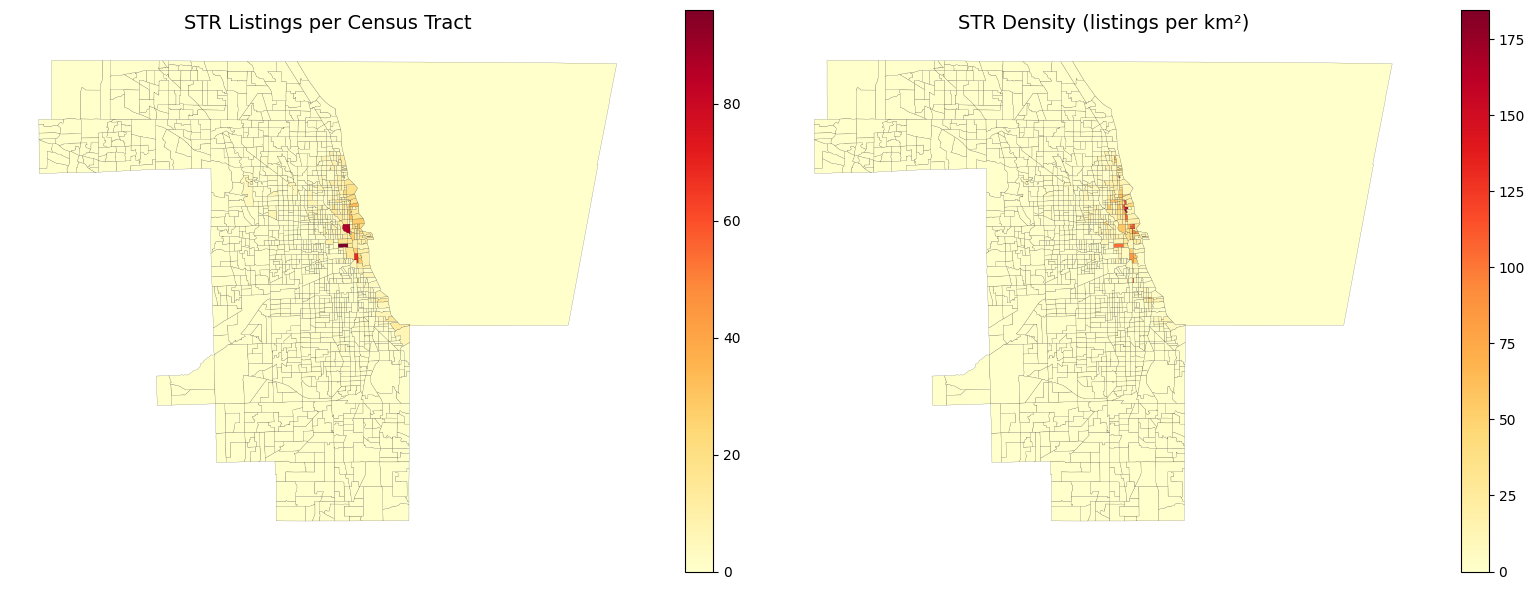

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Count per tract
str_tracts.plot(
    column="point_count",
    cmap="YlOrRd",
    legend=True,
    ax=ax1,
    edgecolor="black",
    linewidth=0.1,
)
ax1.set_title("STR Listings per Census Tract", fontsize=14)
ax1.axis("off")

# Plot 2: Density per km²
str_tracts.plot(
    column="point_density",
    cmap="YlOrRd",
    legend=True,
    ax=ax2,
    edgecolor="black",
    linewidth=0.1,
)
ax2.set_title("STR Density (listings per km²)", fontsize=14)
ax2.axis("off")

plt.tight_layout()
plt.savefig("/project/output/str_tract_density.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
str_community_level = pipeline.context["community_str_data"]

print(str_community_level.head())
print(
    str_community_level["point_count"].min(), str_community_level["point_count"].max()
)

  area_numbe       community area_num_1     shape_area      shape_len  \
0          1     ROGERS PARK          1  51259902.4506  34052.3975757   
1          2      WEST RIDGE          2  98429094.8621  43020.6894583   
2          3          UPTOWN          3  65095642.7289  46972.7945549   
3          4  LINCOLN SQUARE          4  71352328.2399  36624.6030848   
4          5    NORTH CENTER          5    57054167.85  31391.6697542   

                                            geometry community_area  \
0  MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ...              1   
1  MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ...              2   
2  MULTIPOLYGON (((-87.64102 41.95480, -87.64400 ...              3   
3  MULTIPOLYGON (((-87.67441 41.97610, -87.67440 ...              4   
4  MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ...              5   

   community_name  point_count  area_km2  point_density  
0     ROGERS PARK         60.0  4.758656      12.608601  
1      WEST RIDGE 

In [16]:
print(
    str_community_level[
        ["community_name", "point_count", "area_km2", "point_density"]
    ].head()
)

   community_name  point_count  area_km2  point_density
0     ROGERS PARK         60.0  4.758656      12.608601
1      WEST RIDGE         37.0  9.137658       4.049178
2          UPTOWN        115.0  6.043043      19.030148
3  LINCOLN SQUARE         41.0  6.623966       6.189645
4    NORTH CENTER         50.0  5.296593       9.440030


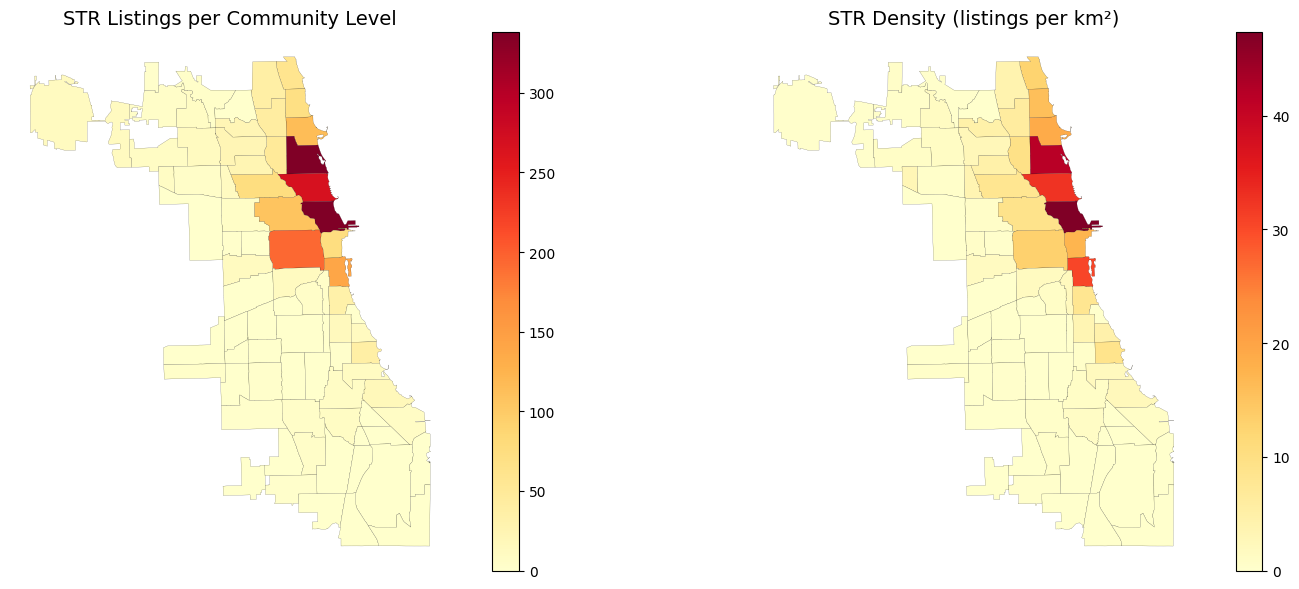

In [17]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
str_community_level.plot(
    column="point_count",
    cmap="YlOrRd",
    legend=True,
    ax=ax1,
    edgecolor="black",
    linewidth=0.1,
)
ax1.set_title("STR Listings per Community Level", fontsize=14)
ax1.axis("off")

# Plot 2: Density per km²
str_community_level.plot(
    column="point_density",
    cmap="YlOrRd",
    legend=True,
    ax=ax2,
    edgecolor="black",
    linewidth=0.1,
)
ax2.set_title("STR Density (listings per km²)", fontsize=14)
ax2.axis("off")

plt.tight_layout()
plt.savefig("/project/output/str_community_density.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from housing.components.loaders.community_boundaries import CommunityBoundariesLoader
from housing.components.processors.str_points_to_tract import STRToTractProcessor
from housing.components.processors.str_tract_to_community import (
    STRTractToCommunityProcessor,
)
from housing.components.visualizers.str_map import STRMapVisualizer